# **Cubo Gelatinoso -**  Aprendizado de Máquina

Prof. Dr. Daniel R. Cassar <br>
Aluno Giovanni A. Moreira (2610060) <br>
Setembro de 2026

## **1. Introdução**

Um algoritmo de aprendizado de máquina utiliza **dados** para induzir um **modelo preditivo**. Assim como uma função matemática recebe **x** e retorna **y**, um modelo preditivo recebe **dados** e, a partir deles, é capaz de retornar uma ou mais previsões. [1]

O **$k$-Nearest Neighbours ($k$-NN)** é um dos muitos algoritmos criados dentro da área de aprendizado de máquina que, segundo Cassar (2026), "[...] é um algoritmo de aprendizado de máquina baseado na hipótese que dados similares ocupam regiões próximas no espaço de entrada (isto é, no espaço dos atributos).". 

Nesse *Python notebook*, o algoritmo *$k$-NN* é utilizado para **induzir um modelo** que seja capaz de **estimar a quantidade de mercúrio em peixes**. Para isso, foram avaliados **quinze conjuntos de hiperparâmetros** - obtidos pela variação no número de vizinhos considerado ($k$) e a métrica de distância utilizada, euclidiana, manhattan e chebyshev - em dados **com e sem normalização**. Por fim, o desempenho de cada configuração foi avaliado por meio do **erro absoluto médio** (MAE) e **R²**, afim de identificar qual **combinação de hiperparâmetros** apresentou melhores resultados.

## **2. Metodologia**

O *dataset* sobre *fish tissue plugs* escolhido para essa atividade é proveniente da *National Aquatic Research Surveys (NARS)*, retirado do site *U.S. Environmental Protection Agency (U.S. EPA)*. Ele conta com 40 atributos, sendo 11 deles numéricos e 29 categóricos, e 910 exemplos de peixes.

### *2.1. Carregamento, tratamento e tradução dos dados*

In [1]:
#Importação da biblioteca pandas
import pandas as pd

A célula abaixo extrai os dados de um arquivo .csv por meio da biblioteca **Pandas**.

In [2]:
# Extrai o DataFrame do arquivo .csv presente no repositório
df_inicial = pd.read_csv("ncca20_hg_fishplug.csv")

# Mostra, por meio de uma lista, quais são as colunas do DF
print(list(df_inicial.columns))

['PUBLICATION_DATE', 'UID', 'UNIQUE_ID', 'SITE_ID', 'VISIT_NO', 'DATE_COL', 'ACTUAL_DATE', 'PSTL_CODE', 'WTBDY_TYPE', 'NCCA_REG', 'GREAT_LAKE', 'LAB', 'SAMPLE_TYPE', 'MATRIX', 'ANALYTE', 'SAM_CODE', 'CAS_NO', 'BATCH_ID', 'SAMPLE_ID', 'LAB_SAMPLE_ID', 'RESULT', 'RESULT_UNITS', 'MDL', 'RL', 'HOLDING_TIME', 'DILUTION', 'ARRIVAL_TEMP', 'CONDITION_CODE', 'DATE_ANALYZED', 'METHOD', 'INSTRUMENT', 'CONDITION_COMMENT', 'FROM_FTIS', 'NAME_SCI', 'LENGTH_1', 'LENGTH_2', 'WEIGHT_1', 'WEIGHT_2', 'NARS_FLAG', 'NARS_COMMENT']


Como o *dataset* escolhido apresenta alguns atributos categóricos nominais que dizem respeito apenas a identificação da amostra - o que não é tão interessante para indução de modelos preditivos - por isso, eles serão filtrados do *data frame*.

In [3]:
# Define as colunas que serão removidas
colunas_para_remocao = [
"PUBLICATION_DATE", "UID", "UNIQUE_ID", "SITE_ID", "VISIT_NO", 
"LAB", "SAMPLE_TYPE", "MATRIX", "ANALYTE", "SAM_CODE",
"CAS_NO", "BATCH_ID", "SAMPLE_ID", "LAB_SAMPLE_ID", "RESULT_UNITS",
"MDL", "RL", "HOLDING_TIME", "DILUTION", "ARRIVAL_TEMP",
"CONDITION_CODE", "DATE_ANALYZED", "METHOD", "INSTRUMENT", "CONDITION_COMMENT", 
"FROM_FTIS", "LENGTH_2", "WEIGHT_2", "NARS_FLAG", "NARS_COMMENT"
]

# "Dropa" (remove) as colunas do data frame
df_filtrado = df_inicial.drop(colunas_para_remocao, axis=1)

# Imprime o data frame até o atual momento
df_filtrado

,DATE_COL,ACTUAL_DATE,PSTL_CODE,WTBDY_TYPE,NCCA_REG,GREAT_LAKE,RESULT,NAME_SCI,LENGTH_1,WEIGHT_1
0,6/1/2020,NaN,TX,MARINE,Gulf,NaN,11.5,Micropogonias undulatus,250.0,200
1,6/2/2020,NaN,MI,GREAT_LAKES,Great Lakes,Lake Superior,190.0,Lota lota,434.0,540
2,6/3/2020,NaN,TX,MARINE,Gulf,NaN,17.5,Micropogonias undulatus,164.0,80
3,6/3/2020,NaN,MI,GREAT_LAKES,Great Lakes,Lake Superior,84.5,Catostomus catostomus,448.0,900
4,6/2/2020,NaN,TX,MARINE,Gulf,NaN,18.0,Micropogonias undulatus,175.0,80
...,...,...,...,...,...,...,...,...,...,...
905,7/17/2022,9/20/2020,MI,GREAT_LAKES,Great Lakes,Lake Michigan,58.1,Prosopium cylindraceum,482.0,1080
906,7/17/2022,9/20/2020,MI,GREAT_LAKES,Great Lakes,Lake Michigan,56.3,Prosopium cylindraceum,443.0,760
907,7/18/2022,9/20/2020,MI,GREAT_LAKES,Great Lakes,Lake Michigan,46.8,Prosopium cylindraceum,465.0,920
908,7/16/2022,9/19/2020,MI,GREAT_LAKES,Great Lakes,Lake Michigan,140.0,Salvelinus namaycush,628.0,4950


Sobraram 10 atributos, sendo um deles "*RESULT*", o target escolhido.

Ainda há um tratamento a ser feito referente as datas de coleta. Ambas colunas "DATE_COL" e "ACTUAL_DATE" mostram a data em que a coleta da amostra foi feita, porém, algumas delas da primeira coluna estão "erradas" (com um *gap* de até 2 anos). Os valores corretos estão presentes na segunda coluna, "ACTUAL_DATE"; por isso, todas as datas "erráticas" serão substituídas por seus correspondentes valores corretos.

In [4]:
# Preenche os valores NaN presentes em "ACTUAL_DATE" e atribui tudo isso a uma nova coluna
df_filtrado["REAL_DATE_COL"] = df_filtrado["ACTUAL_DATE"].fillna(df_filtrado["DATE_COL"])

# Tira as colunas antigas de data
df_corrigido2 = df_filtrado.drop(["ACTUAL_DATE", "DATE_COL"], axis=1)

# Imprime o data frame com data corrigida
df_corrigido2

,PSTL_CODE,WTBDY_TYPE,NCCA_REG,GREAT_LAKE,RESULT,NAME_SCI,LENGTH_1,WEIGHT_1,REAL_DATE_COL
0,TX,MARINE,Gulf,NaN,11.5,Micropogonias undulatus,250.0,200,6/1/2020
1,MI,GREAT_LAKES,Great Lakes,Lake Superior,190.0,Lota lota,434.0,540,6/2/2020
2,TX,MARINE,Gulf,NaN,17.5,Micropogonias undulatus,164.0,80,6/3/2020
3,MI,GREAT_LAKES,Great Lakes,Lake Superior,84.5,Catostomus catostomus,448.0,900,6/3/2020
4,TX,MARINE,Gulf,NaN,18.0,Micropogonias undulatus,175.0,80,6/2/2020
...,...,...,...,...,...,...,...,...,...
905,MI,GREAT_LAKES,Great Lakes,Lake Michigan,58.1,Prosopium cylindraceum,482.0,1080,9/20/2020
906,MI,GREAT_LAKES,Great Lakes,Lake Michigan,56.3,Prosopium cylindraceum,443.0,760,9/20/2020
907,MI,GREAT_LAKES,Great Lakes,Lake Michigan,46.8,Prosopium cylindraceum,465.0,920,9/20/2020
908,MI,GREAT_LAKES,Great Lakes,Lake Michigan,140.0,Salvelinus namaycush,628.0,4950,9/19/2020


Os atributo "**WTBDY_TYPE**" e "**GREAT_LAKE**" apresentam informações semelhantes. No entanto, enquanto o primeiro indica apenas o tipo de corpo da água em que o peixe foi capturado (marinho ou pluvial), o segundo fornece informações mais específicas sobre a região de origem da amostra. Dessa forma, os valores ausentes da coluna "**GREAT_LAKE**", presentes exclusivamente em registros classificados como "**MARINE**" em "**WTBDY_TYPE**", foram substituidos por "Ocean". Com isso, a *feature* "**WTBDY_TYPE**" será removida do *dataset* para as próximas etapas da análise.

In [5]:
# Preenche "Ocean" no lugar dos valores NaN em "NCCA_REG"
df_corrigido2["GREAT_LAKE"] = df_corrigido2["GREAT_LAKE"].fillna("Ocean")

# Tira a coluna "WTBDY_TYPE"
df_corrigido2 = df_corrigido2.drop(["WTBDY_TYPE"], axis=1)

# Imprime o dataset após as alterações
df_corrigido2

,PSTL_CODE,NCCA_REG,GREAT_LAKE,RESULT,NAME_SCI,LENGTH_1,WEIGHT_1,REAL_DATE_COL
0,TX,Gulf,Ocean,11.5,Micropogonias undulatus,250.0,200,6/1/2020
1,MI,Great Lakes,Lake Superior,190.0,Lota lota,434.0,540,6/2/2020
2,TX,Gulf,Ocean,17.5,Micropogonias undulatus,164.0,80,6/3/2020
3,MI,Great Lakes,Lake Superior,84.5,Catostomus catostomus,448.0,900,6/3/2020
4,TX,Gulf,Ocean,18.0,Micropogonias undulatus,175.0,80,6/2/2020
...,...,...,...,...,...,...,...,...
905,MI,Great Lakes,Lake Michigan,58.1,Prosopium cylindraceum,482.0,1080,9/20/2020
906,MI,Great Lakes,Lake Michigan,56.3,Prosopium cylindraceum,443.0,760,9/20/2020
907,MI,Great Lakes,Lake Michigan,46.8,Prosopium cylindraceum,465.0,920,9/20/2020
908,MI,Great Lakes,Lake Michigan,140.0,Salvelinus namaycush,628.0,4950,9/19/2020


Agora o nome das colunas será traduzido por preferência pessoal e para melhor compreensão ao longo do notebook.

In [6]:
# Cria uma lista com os nomes das colunas traduzidos
colunas_traduzidas = [
"Estado", "Região",
"Local de coleta", "Concentração de Hg (ng/g)", "Espécie",
"Comprimento (mm)", "Peso (g)", "Data de coleta"
]

# Traduz as colunas
df_corrigido2.columns = colunas_traduzidas

# Dropa os valores NaN
df_corrigido2 = df_corrigido2.dropna(axis=0)

df_corrigido2

,Estado,Região,Local de coleta,Concentração de Hg (ng/g),Espécie,Comprimento (mm),Peso (g),Data de coleta
0,TX,Gulf,Ocean,11.5,Micropogonias undulatus,250.0,200,6/1/2020
1,MI,Great Lakes,Lake Superior,190.0,Lota lota,434.0,540,6/2/2020
2,TX,Gulf,Ocean,17.5,Micropogonias undulatus,164.0,80,6/3/2020
3,MI,Great Lakes,Lake Superior,84.5,Catostomus catostomus,448.0,900,6/3/2020
4,TX,Gulf,Ocean,18.0,Micropogonias undulatus,175.0,80,6/2/2020
...,...,...,...,...,...,...,...,...
905,MI,Great Lakes,Lake Michigan,58.1,Prosopium cylindraceum,482.0,1080,9/20/2020
906,MI,Great Lakes,Lake Michigan,56.3,Prosopium cylindraceum,443.0,760,9/20/2020
907,MI,Great Lakes,Lake Michigan,46.8,Prosopium cylindraceum,465.0,920,9/20/2020
908,MI,Great Lakes,Lake Michigan,140.0,Salvelinus namaycush,628.0,4950,9/19/2020


In [7]:
df_corrigido2 = df_corrigido2.convert_dtypes()

df_corrigido2.dtypes

Estado                       string[python]
Região                       string[python]
Local de coleta              string[python]
Concentração de Hg (ng/g)           Float64
Espécie                      string[python]
Comprimento (mm)                    Float64
Peso (g)                     string[python]
Data de coleta               string[python]
dtype: object

Aqui temos um problema, atributos como Peso (g) e a Data de coleta são strings quando, na verdade, deveriam ser do seus respectivos tipos. Para corrigir isso o comando "to_numeric" e "to_datetime" é aplicado na próxima célula.

In [8]:
# Transforma as strings do atributo peso em float
df_corrigido2["Peso (g)"] = pd.to_numeric(df_corrigido2["Peso (g)"].astype(str).str.replace(",", ""))

# Transforma as strings do atributo data em um tipo mais adequado para manipulação
df_corrigido2["Data de coleta"] = pd.to_datetime(df_corrigido2["Data de coleta"])

### *2.2. Análise exploratória de dados e seleção de atributos*

A Análise Exploratória de Dados (AED) é uma prática fundamental para compreensão estatística de dados, com ela é possível compreender a estrutura dos dados, identificar determinados padrões, detectar de possíveis erros e, em um geral, obter informações relevantes para tomada de decisões e/ou ações sobre determinada problemática. A AED presente nesta seção é essencial para a seleção de atributos para a indução do modelo preditivo.

Tendo como *target* a concentração de mercúrio por grama de amostra, busca-se checar a relação entre o alvo e os demais atributos pré-selecionados. Por isso, gráficos foram gerados para tornar visível a relação que as *features* possuem (ou não) com o *target*.

In [9]:
# Importação de bibliotecas para criação de gráficos
import seaborn as sns
import matplotlib.pyplot as plt

Afim de observar a relação do peso com a concentração e do comprimento com a concentração foram criados os dois gráficos abaixo.

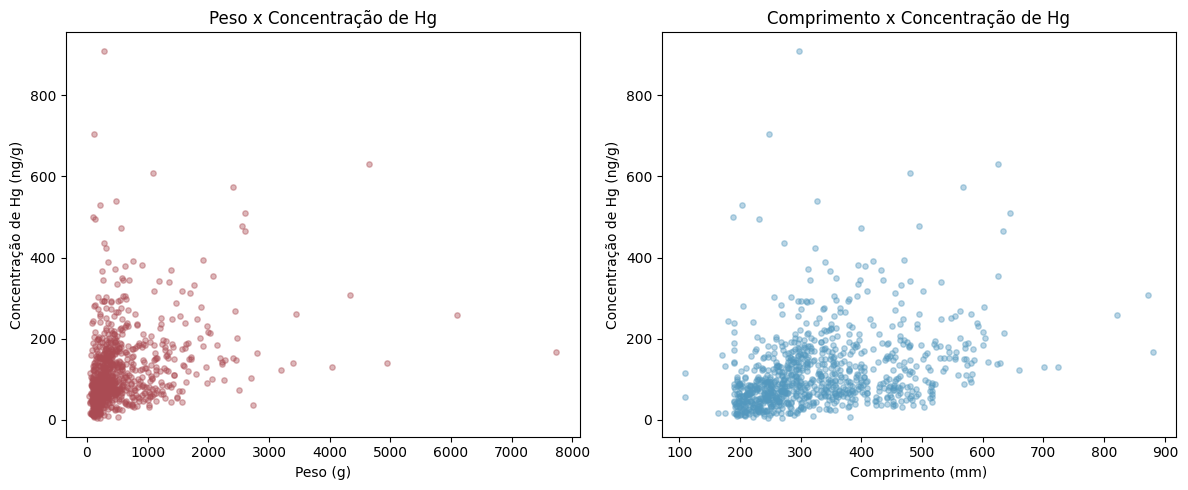

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1
axes[0].scatter(
    df_corrigido2["Peso (g)"],
    df_corrigido2["Concentração de Hg (ng/g)"], 
    alpha=0.4,
    s=15, 
    color="#AA4B53"
)
axes[0].set_title("Peso x Concentração de Hg")
axes[0].set_ylabel("Concentração de Hg (ng/g)")
axes[0].set_xlabel("Peso (g)")

# Gráfico 2
axes[1].scatter(
    df_corrigido2["Comprimento (mm)"],
    df_corrigido2["Concentração de Hg (ng/g)"],
    alpha=0.4, 
    s=15,
    color="#5398BE"
)
axes[1].set_title("Comprimento x Concentração de Hg")
axes[1].set_ylabel("Concentração de Hg (ng/g)")
axes[1].set_xlabel("Comprimento (mm)")

plt.tight_layout()
plt.show()

Os gráficos de dispersão indicam uma possível relação entre o peso, comprimento e a concentração de mercúrio, embora essa associação não seja muito forte. Ainda sim, esses resultados justificam a permanência desses atributos na indução do modelo.

Também foi criado um gráfico que testa a relação entre a data de coleta e a concentração de mercúrio.

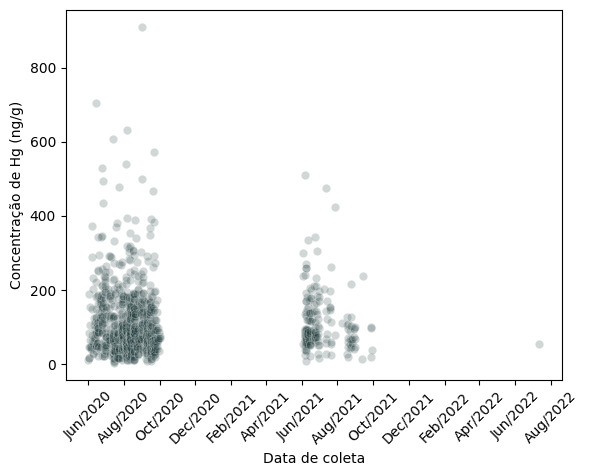

In [97]:
import matplotlib.dates as mdates

df_grafico_datas = df_corrigido2[["Data de coleta", "Concentração de Hg (ng/g)"]].sort_values("Data de coleta")

grafico_datas = sns.scatterplot(
    data=df_grafico_datas,
    x="Data de coleta",
    y="Concentração de Hg (ng/g)",
    alpha=0.2,
    color="#1C3738"
)

locator = mdates.MonthLocator(interval=2)              
formatter = mdates.DateFormatter('%b/%Y')    
grafico_datas.xaxis.set_major_locator(locator)
grafico_datas.xaxis.set_major_formatter(formatter)
plt.xticks(rotation=45)

plt.show()


Através do gráfico é possível observar que não há uma relação clara entre a data de coleta e a concentração de mercúrio. Além disso, a maior parte das amostras foi coletada em 2020, o que pode dificultar a identificação de possíveis tendências ao longo do tempo. Levando esses fatores em consideração, a variável data de coleta não será utilizada nas etapas posteriores.

Por fim, foram gerados três gráficos para analisar a relação entre atributos ligados ao local de coleta, como estado, região e local de coleta, e a concentração de mercúrio nas amostras.

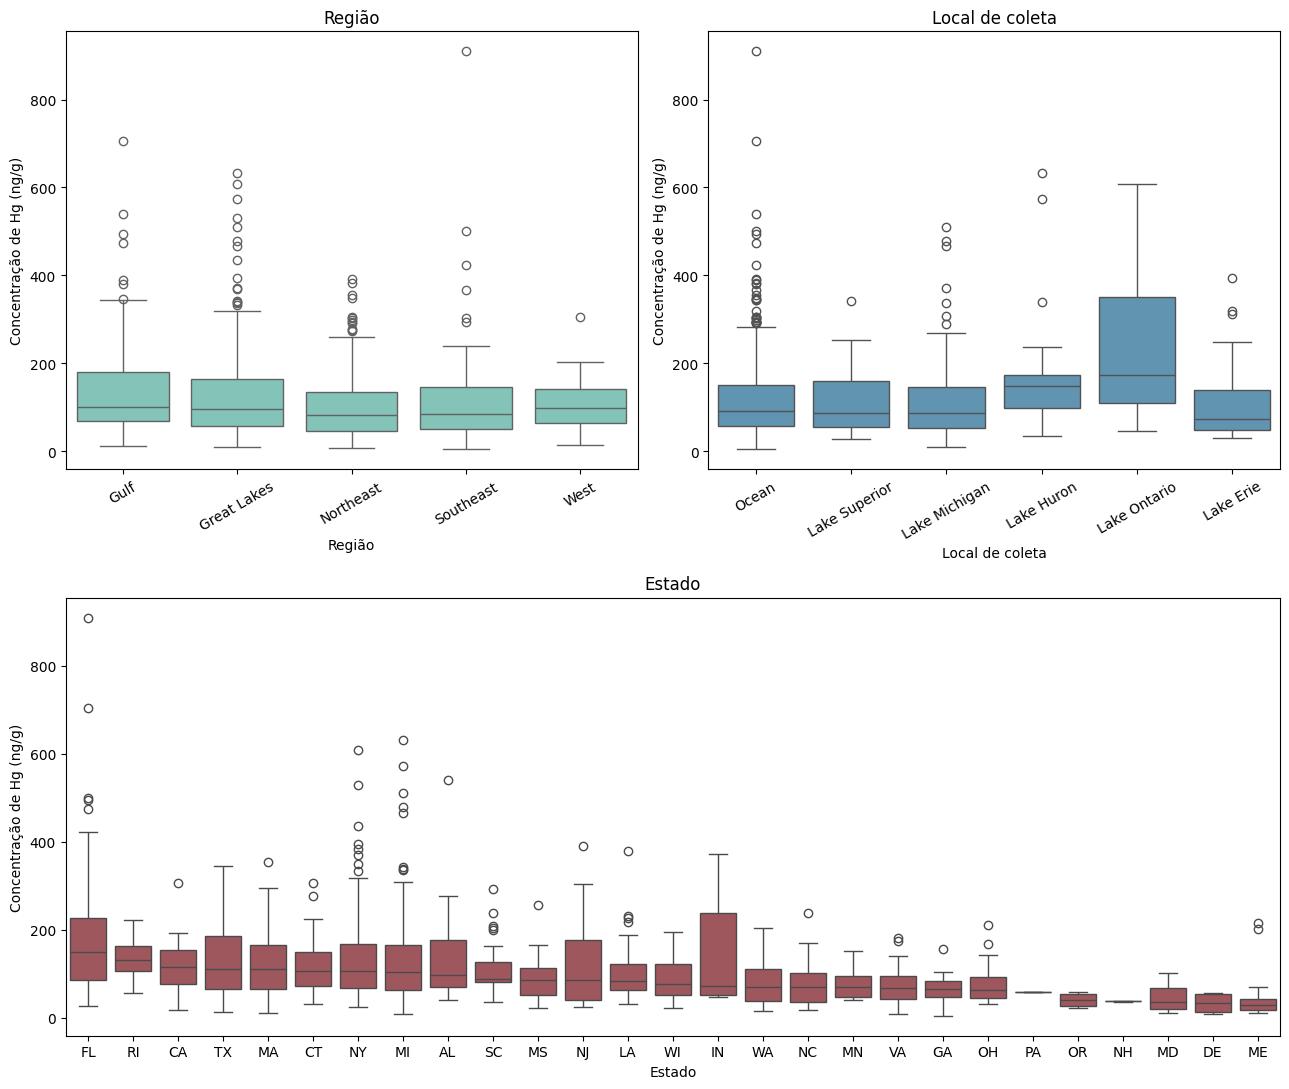

In [115]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(13, 11))
gs = gridspec.GridSpec(2, 2, figure=fig)

axes = [
    fig.add_subplot(gs[0, 0]),   
    fig.add_subplot(gs[0, 1]),   
    fig.add_subplot(gs[1, :]),   
]

# Gráfico 1
sns.boxplot(data=df_corrigido2,
x="Região", 
y="Concentração de Hg (ng/g)", 
ax=axes[0],
color="#79CDBF"
)
axes[0].set_title("Região")
axes[0].tick_params(axis="x", rotation=30)

# Gráfico 2
sns.boxplot(data=df_corrigido2,
x="Local de coleta", 
y="Concentração de Hg (ng/g)", 
ax=axes[1],
color="#5398BE"
)
axes[1].set_title("Local de coleta")
axes[1].tick_params(axis="x", rotation=30)

# Gráfico 3
ordem_estados = df_corrigido2.groupby("Estado")["Concentração de Hg (ng/g)"].median().sort_values(ascending=False).index

sns.boxplot(
data=df_corrigido2, 
x="Estado", 
y="Concentração de Hg (ng/g)", 
order=ordem_estados, 
color="#AA4B53"
)
axes[2].set_title("Estado")

plt.tight_layout()
plt.show()

Por meio dos gráficos, é possível observar que o local de coleta e o estado apresentam relação mais evidente com a concentração de mercúrio, enquanto as regiões possuem distribuições semelhantes e bastante sobrepostas. Além disso, o atributo região apresenta informações menos específicas do que o estado por exemplo. Levando esses fatores em consideração, a variável região não será utilizada nas etapas posteriores.



<Axes: xlabel='Concentração de Hg (ng/g)', ylabel='Espécie agrupada'>

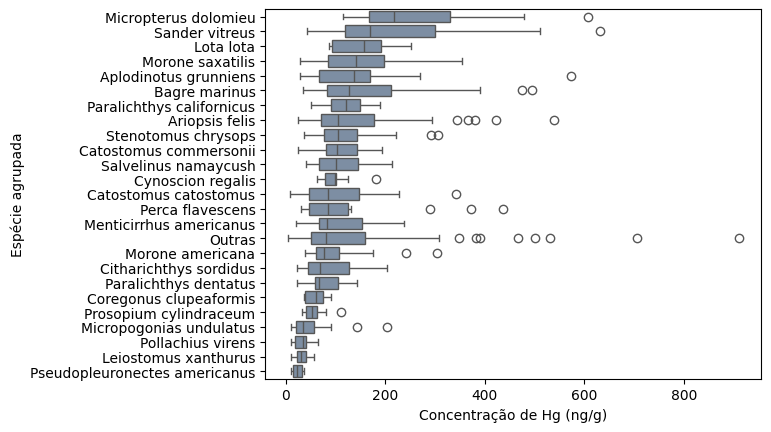

In [116]:
contagem_especies = df_corrigido2["Espécie"].value_counts()
especies_frequentes = contagem_especies[contagem_especies >= 10].index

df_corrigido2["Espécie agrupada"] = df_corrigido2["Espécie"].where(
    df_corrigido2["Espécie"].isin(especies_frequentes), "Outras"
)

ordem_especies = df_corrigido2.groupby("Espécie agrupada")["Concentração de Hg (ng/g)"].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_corrigido2,
    y="Espécie agrupada",
    x="Concentração de Hg (ng/g)",
    order=ordem_especies,
    color="#778DA9"
)

Através do gráfico, é possível observar uma relação clara entre a espécie e a concentração de mercúrio. Algumas espécies apresentam medianas e variações consideravelmente maiores, enquanto outras possuem concentrações mais baixas e homogêneas. Levando esses fatores em consideração, o atributo espécie será mantido nas etapas posteriores, pois pode contribuir significativamente para a previsão do target.

In [14]:
df_peixes = df_corrigido2.drop(["Região", "Espécie", "Data de coleta"], axis=1)

df_peixes

,Estado,Local de coleta,Concentração de Hg (ng/g),Comprimento (mm),Peso (g),Espécie agrupada
0,TX,Ocean,11.5,250.0,200.0,Micropogonias undulatus
1,MI,Lake Superior,190.0,434.0,540.0,Lota lota
2,TX,Ocean,17.5,164.0,80.0,Micropogonias undulatus
3,MI,Lake Superior,84.5,448.0,900.0,Catostomus catostomus
4,TX,Ocean,18.0,175.0,80.0,Micropogonias undulatus
...,...,...,...,...,...,...
905,MI,Lake Michigan,58.1,482.0,1080.0,Prosopium cylindraceum
906,MI,Lake Michigan,56.3,443.0,760.0,Prosopium cylindraceum
907,MI,Lake Michigan,46.8,465.0,920.0,Prosopium cylindraceum
908,MI,Lake Michigan,140.0,628.0,4950.0,Salvelinus namaycush


### *2.3. Divisão entre treino e teste*

In [15]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 12788

indices = df_peixes.index
indices_treino, indices_teste = train_test_split(
    indices,
    test_size=TAMANHO_TESTE,
    random_state=SEMENTE_ALEATORIA
)

df_treino = df_peixes.loc[indices_treino]
df_teste = df_peixes.loc[indices_teste]


### *2.4. Codificação e normalização dos dados*

In [16]:
from sklearn.preprocessing import OneHotEncoder

colunas_cat_treino = df_treino[["Local de coleta", "Estado", "Espécie agrupada"]]
colunas_cat_teste = df_teste[["Local de coleta", "Estado", "Espécie agrupada"]]

encoder = OneHotEncoder(sparse_output=False)
encoder.fit(colunas_cat_treino)

X_cat_treino = encoder.transform(colunas_cat_treino)
X_cat_teste = encoder.transform(colunas_cat_teste)

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

colunas_num_treino = df_treino[["Comprimento (mm)", "Peso (g)"]]
colunas_num_teste = df_teste[["Comprimento (mm)", "Peso (g)"]]

# Normalização por StandardScaler
normalizador_1 = StandardScaler()
normalizador_1.fit(colunas_num_treino)

X_num_treino = normalizador_1.transform(colunas_num_treino)
X_num_teste = normalizador_1.transform(colunas_num_teste)

# Normalização por MinMaxScaler
normalizador_2 = MinMaxScaler()
normalizador_2.fit(colunas_num_treino)

X_num_treino_mms = normalizador_2.transform(colunas_num_treino)
X_num_teste_mms = normalizador_2.transform(colunas_num_teste)


In [125]:
import numpy as np

# X codificado e normalizado por StandardScaler
X_treino_ss = np.hstack([X_cat_treino, X_num_treino])
X_teste_ss = np.hstack([X_cat_teste, X_num_teste])

# X codificado e normalizado por MinMaxScaler
X_treino_mms = np.hstack([X_cat_treino, X_num_treino_mms])
X_teste_mms = np.hstack([X_cat_teste, X_num_teste_mms])

# Y continua igual pro dois
y_treino = df_treino["Concentração de Hg (ng/g)"]
y_teste = df_teste["Concentração de Hg (ng/g)"]

### *2.5. Modelo baseline*
dummy regressor larping

In [126]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

baseline = DummyRegressor()
baseline.fit(X_treino_ss, y_treino)
pred_baseline = baseline.predict(X_teste_ss)

print("MAE baseline:", mean_absolute_error(y_teste, pred_baseline))
print("R² baseline:", r2_score(y_teste, pred_baseline))

MAE baseline: 73.47692145692145
R² baseline: -0.004443793838727839


### *2.6. Modelo K-Nearest Neighbours* 

In [127]:
from sklearn.neighbors import KNeighborsRegressor

valores_k = [3, 5, 7, 9, 11]
metricas = ["euclidean", "manhattan", "chebyshev"]

resultados = []

for metrica in metricas:
    for k in valores_k:

        modelo = KNeighborsRegressor(n_neighbors=k, metric=metrica)
        modelo.fit(X_treino_ss, y_treino)
        pred_knn = modelo.predict(X_teste_ss)

        resultados.append({
            "Distância":metrica,
            "Nº vizinhos":k,
            "MAE":mean_absolute_error(y_teste, pred_knn),
            "R²":r2_score(y_teste, pred_knn)
        })

df_resultados_1 = pd.DataFrame(resultados)
df_resultados_1

,Distância,Nº vizinhos,MAE,R²
0,euclidean,3,56.794286,0.139064
1,euclidean,5,53.020615,0.248464
2,euclidean,7,49.366232,0.336608
3,euclidean,9,52.834347,0.282055
4,euclidean,11,54.249121,0.247826
5,manhattan,3,58.004542,0.129207
6,manhattan,5,53.401934,0.260077
7,manhattan,7,51.073454,0.317680
8,manhattan,9,51.901136,0.288722
9,manhattan,11,53.476693,0.259608


In [128]:
valores_k = [3, 5, 7, 9, 11]
metricas = ["euclidean", "manhattan", "chebyshev"]

resultados = []

for metrica in metricas:
    for k in valores_k:

        modelo = KNeighborsRegressor(n_neighbors=k, metric=metrica)
        modelo.fit(X_treino_mms, y_treino)
        pred_knn = modelo.predict(X_teste_mms)

        resultados.append({
            "Distância":metrica,
            "Nº vizinhos":k,
            "MAE":mean_absolute_error(y_teste, pred_knn),
            "R²":r2_score(y_teste, pred_knn)
        })

df_resultados_2 = pd.DataFrame(resultados)
df_resultados_2

,Distância,Nº vizinhos,MAE,R²
0,euclidean,3,55.452527,0.174305
1,euclidean,5,52.953802,0.247494
2,euclidean,7,50.386641,0.327853
3,euclidean,9,51.448022,0.301829
4,euclidean,11,52.562148,0.263672
5,manhattan,3,54.884396,0.177668
6,manhattan,5,52.976220,0.253812
7,manhattan,7,49.748336,0.344661
8,manhattan,9,51.857912,0.299591
9,manhattan,11,52.343467,0.276343


## **3. Resultados e discussão**

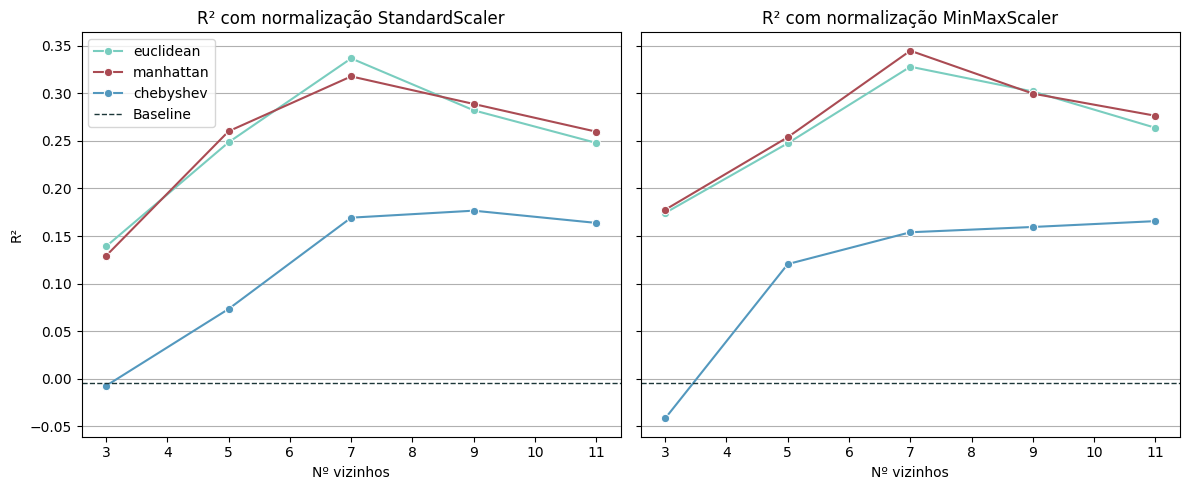

In [133]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# R² sem normalização
sns.lineplot(
    data=df_resultados_1,
    x="Nº vizinhos",
    y="R²",
    hue="Distância",
    marker="o",
    palette=["#79CDBF", "#AA4B53", "#5398BE"],
    ax=ax[0]
)
ax[0].set_title("R² com normalização StandardScaler")
ax[0].axhline(-0.004443793838727839, color="#1C3738", linestyle="--", linewidth=1, label="Baseline")
ax[0].grid(axis="y")
ax[0].legend(loc="upper left")

# R² normalizado
sns.lineplot(
    data=df_resultados_2,
    x="Nº vizinhos",
    y="R²",
    hue="Distância",
    marker="o",
    palette=["#79CDBF", "#AA4B53", "#5398BE"],
    ax=ax[1],
    legend=False
)
ax[1].set_title("R² com normalização MinMaxScaler")
ax[1].axhline(-0.004443793838727839, color="#1C3738", linestyle="--", linewidth=1, label="Baseline")
ax[1].grid(axis="y")

plt.tight_layout()
plt.show()

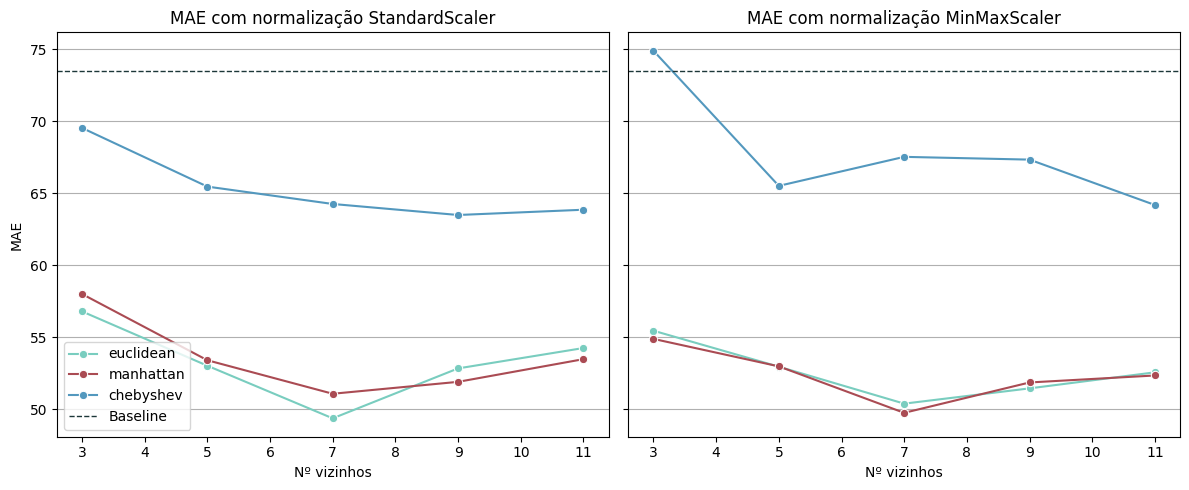

In [134]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# MAE sem normalização
sns.lineplot(
    data=df_resultados_1,
    x="Nº vizinhos",
    y="MAE",
    hue="Distância",
    marker="o",
    palette=["#79CDBF", "#AA4B53", "#5398BE"],
    ax=ax[0]
)
ax[0].set_title("MAE com normalização StandardScaler")
ax[0].axhline(73.47692145692145, color="#1C3738", linestyle="--", linewidth=1, label="Baseline")
ax[0].legend(loc="lower left")
ax[0].grid(axis="y")

# MAE normalizado
sns.lineplot(
    data=df_resultados_2,
    x="Nº vizinhos",
    y="MAE",
    hue="Distância",
    marker="o",
    palette=["#79CDBF", "#AA4B53", "#5398BE"],
    ax=ax[1],
    legend=False
)
ax[1].set_title("MAE com normalização MinMaxScaler")
ax[1].axhline(73.47692145692145, color="#1C3738", linestyle="--", linewidth=1, label="Baseline")
ax[1].grid(axis="y")

plt.tight_layout()
plt.show()

C:\Users\giovanni2610060\AppData\Local\Temp\ipykernel_8220\1021086293.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(


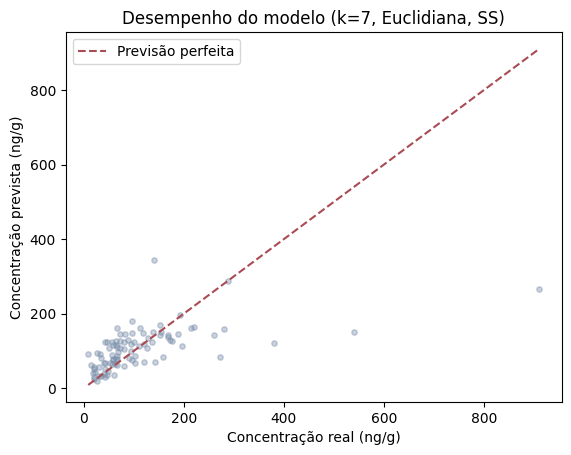

In [138]:
modelo_final = KNeighborsRegressor(n_neighbors=7, metric="manhattan")
modelo_final.fit(X_treino_ss, y_treino)
pred_final = modelo_final.predict(X_teste_ss)

plt.scatter(
    y_teste, 
    pred_final, 
    alpha=0.4, 
    s=15,
    color="#778DA9"
)

plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()],
    "r--", 
    label="Previsão perfeita",
    color="#AA4B53"
)

plt.xlabel("Concentração real (ng/g)")
plt.ylabel("Concentração prevista (ng/g)")
plt.title("Desempenho do modelo (k=7, Euclidiana, SS)")
plt.legend()

plt.show()

## **4. Conclusões e principais aprendizados**

## **Nota sobre uso de IA**

## **Referências**